In [21]:
# https://www.youtube.com/watch?v=CbTU92pbDKw

In [1]:
import yfinance as yf
import pandas as pd

ticker = "GLD"
gold_data = yf.download(
    ticker,
    start="2000-01-01",
    end=None,
    progress=False,
    auto_adjust=False,
    actions=True,
)
gold_data

Price,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
Ticker,GLD,GLD,GLD,GLD,GLD,GLD,GLD,GLD,GLD
Date,,,,,,,,,
2004-11-18,44.380001,0.0,44.380001,0.0,44.490002,44.070000,44.430000,0.0,5992000
2004-11-19,44.779999,0.0,44.779999,0.0,44.919998,44.470001,44.490002,0.0,11655300
2004-11-22,44.950001,0.0,44.950001,0.0,44.970001,44.740002,44.750000,0.0,11996000
2004-11-23,44.750000,0.0,44.750000,0.0,44.919998,44.720001,44.880001,0.0,3169200
2004-11-24,45.049999,0.0,45.049999,0.0,45.049999,44.790001,44.930000,0.0,6105100
...,...,...,...,...,...,...,...,...,...
2025-04-15,297.779999,0.0,297.779999,0.0,298.019989,296.089996,296.929993,0.0,7924100
2025-04-16,307.470001,0.0,307.470001,0.0,308.059998,303.799988,304.649994,0.0,20778100


In [2]:
finbert_score = pd.read_csv("../Final_sentiment_score.csv")
finbert_score = finbert_score[["Date", "Positive", "Neutral", "Negative"]]
finbert_score

,Date,Positive,Neutral,Negative
0,2000-02-15,0.398276,0.585515,0.016209
1,2000-02-17,0.077722,0.095735,0.826543
2,2000-03-24,0.180700,0.287722,0.531578
3,2000-04-27,0.393267,0.346374,0.260358
4,2000-05-04,0.337279,0.255016,0.407705
...,...,...,...,...
3667,2019-01-25,0.786646,0.120372,0.092982
3668,2019-01-28,0.749922,0.169181,0.080897
3669,2019-01-30,0.790114,0.135270,0.074616
3670,2019-01-31,0.128171,0.481111,0.390717


In [3]:
finbert_score["Date"] = pd.to_datetime(finbert_score["Date"])

In [4]:
gold_data.reset_index(inplace=True)
gold_data.columns = [col[0] for col in gold_data.columns]

gold_data["Date"] = pd.to_datetime(gold_data["Date"])

In [5]:
df = gold_data[["Date", "Close"]]

df

,Date,Close
0,2004-11-18,44.380001
1,2004-11-19,44.779999
2,2004-11-22,44.950001
3,2004-11-23,44.750000
4,2004-11-24,45.049999
...,...,...
5133,2025-04-15,297.779999
5134,2025-04-16,307.470001
5135,2025-04-17,306.119995
5136,2025-04-21,315.589996


In [6]:
# make date the index
df.index = df.pop("Date")
df

,Close
Date,
2004-11-18,44.380001
2004-11-19,44.779999
2004-11-22,44.950001
2004-11-23,44.750000
2004-11-24,45.049999
...,...
2025-04-15,297.779999
2025-04-16,307.470001
2025-04-17,306.119995


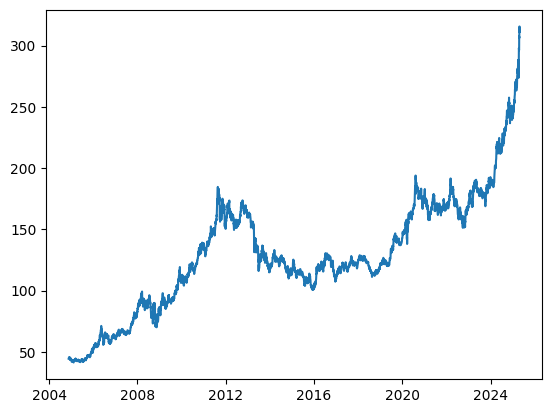

In [7]:
import matplotlib.pyplot as plt

plt.plot(df.index, df["Close"])

In [8]:
import numpy as np
import pandas as pd


def df_to_windowed_df(dataframe, n=3):
    dates = []
    X, Y = [], []

    for i in range(n, len(dataframe)):
        window = dataframe.iloc[i - n : i + 1]  # n previous + 1 target row

        if len(window) != n + 1:
            continue  # skip if not enough data

        values = window[["Close"]].to_numpy()
        x, y = values[:-1], values[-1][0]

        dates.append(dataframe.index[i])  # the date corresponding to the target
        X.append(x.flatten())  # flatten to 1D array of n values
        Y.append(y)

    ret_df = pd.DataFrame({"Target Date": dates})

    X = np.array(X)  # shape (num_samples, n)
    for i in range(n):
        ret_df[f"Target-{n - i}"] = X[:, i]  # each column is Close value at t-n+i

    ret_df["Target"] = Y

    return ret_df

In [9]:
windowed_df = df_to_windowed_df(df, n=3)
windowed_df

,Target Date,Target-3,Target-2,Target-1,Target
0,2004-11-23,44.380001,44.779999,44.950001,44.750000
1,2004-11-24,44.779999,44.950001,44.750000,45.049999
2,2004-11-26,44.950001,44.750000,45.049999,45.290001
3,2004-11-29,44.750000,45.049999,45.290001,45.400002
4,2004-11-30,45.049999,45.290001,45.400002,45.119999
...,...,...,...,...,...
5130,2025-04-15,292.350006,297.929993,296.230011,297.779999
5131,2025-04-16,297.929993,296.230011,297.779999,307.470001
5132,2025-04-17,296.230011,297.779999,307.470001,306.119995
5133,2025-04-21,297.779999,307.470001,306.119995,315.589996


In [10]:
df

,Close
Date,
2004-11-18,44.380001
2004-11-19,44.779999
2004-11-22,44.950001
2004-11-23,44.750000
2004-11-24,45.049999
...,...
2025-04-15,297.779999
2025-04-16,307.470001
2025-04-17,306.119995


In [11]:
# date, Input -> X, output -> Y
def windowed_df_to_date_X_y(windowed_dataframe):
    df_as_np = windowed_dataframe.to_numpy()

    # getting the dates
    dates = df_as_np[:, 0]

    # we want the target window columns only and not the last one
    middle_matrix = df_as_np[:, 1:-1]
    # we need to reshape this
    X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))

    # ouput vector
    Y = df_as_np[:, -1]

    return dates, X.astype(np.float32), Y.astype(np.float32)


dates, X, y = windowed_df_to_date_X_y(windowed_df)

# check all the shapes
dates.shape, X.shape, y.shape

((5135,), (5135, 3, 1), (5135,))

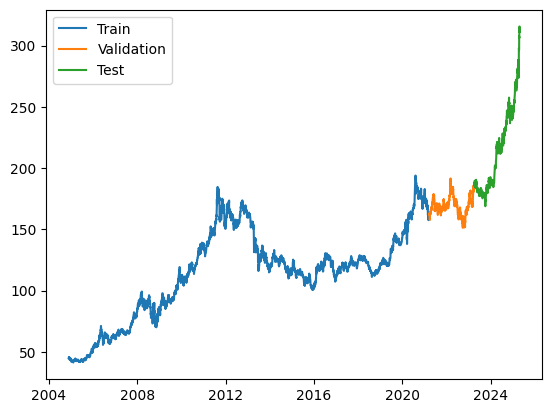

In [12]:
# training part
q_80 = int(len(dates) * 0.8)

# validation part
q_90 = int(len(dates) * 0.9)

dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]
dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(["Train", "Validation", "Test"])

In [22]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [24]:
!nvidia-smi

Wed Apr 23 01:31:13 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.65                 Driver Version: 566.07         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4050 ...    On  |   00000000:01:00.0  On |                  N/A |
| N/A   45C    P5              5W /   96W |    3977MiB /   6141MiB |     30%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:$CONDA_PREFIX/lib/
export TF_FORCE_GPU_ALLOW_GROWTH=true


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

model = Sequential(
    [
        layers.Input((3, 1)),  # window size = 3, feature = 1
        layers.LSTM(64),
        layers.Dense(32, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ]
)  # since the output we want is just 1

model.compile(
    loss="mse", optimizer=Adam(learning_rate=0.001), metrics=["mean_absolute_error"]
)

model.fit(
    X_train, y_train, validation_data=(X_val, y_val), epochs=100
)  # 100 runs through the dataset

Epoch 1/100


E0000 00:00:1745386290.653940  341998 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.1.0 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
2025-04-23 01:31:30.868261: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at cudnn_rnn_ops.cc:1769 : INVALID_ARGUMENT: Dnn is not supported


InvalidArgumentError: Graph execution error:

Detected at node sequential_6_1/lstm_6_1/CudnnRNNV3 defined at (most recent call last):
  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main

  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code

  File "/home/arko/VSC/IDS_705_Final_Project/.venv/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/arko/VSC/IDS_705_Final_Project/.venv/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/arko/VSC/IDS_705_Final_Project/.venv/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/home/arko/VSC/IDS_705_Final_Project/.venv/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/usr/lib/python3.10/asyncio/base_events.py", line 603, in run_forever

  File "/usr/lib/python3.10/asyncio/base_events.py", line 1909, in _run_once

  File "/usr/lib/python3.10/asyncio/events.py", 

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


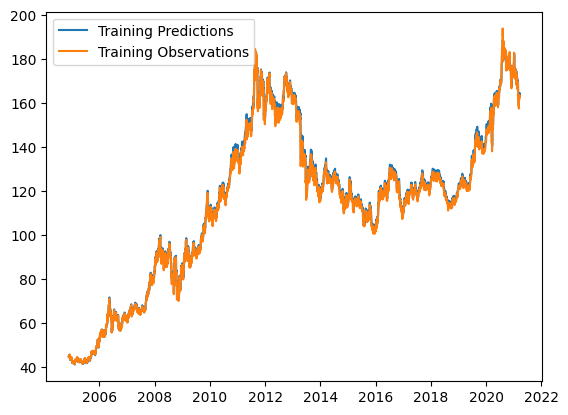

In [ ]:
train_predictions = model.predict(X_train).flatten()

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.legend(["Training Predictions", "Training Observations"])

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 760us/step


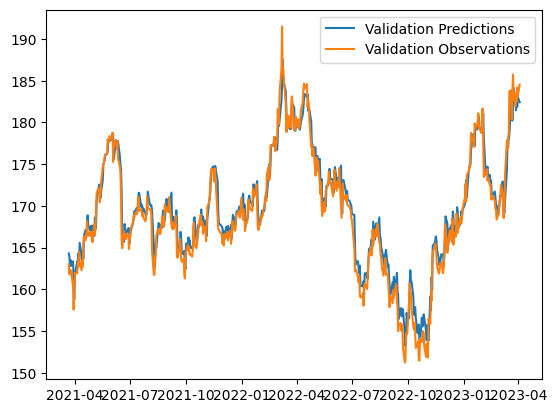

In [ ]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(["Validation Predictions", "Validation Observations"])

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 733us/step


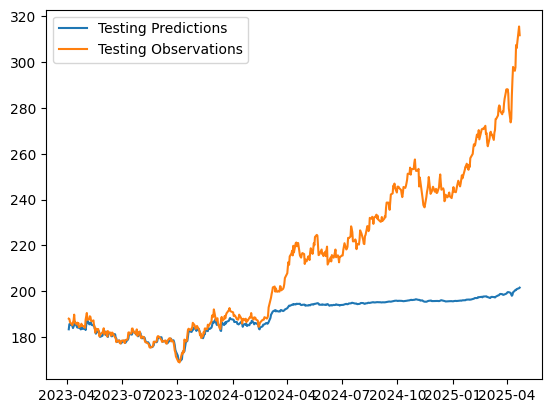

In [ ]:
test_predictions = model.predict(X_test).flatten()

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(["Testing Predictions", "Testing Observations"])

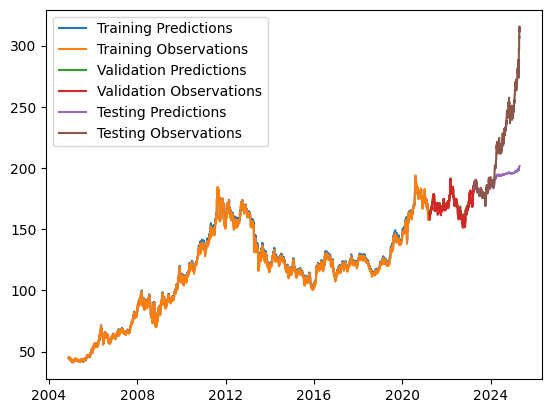

In [ ]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(
    [
        "Training Predictions",
        "Training Observations",
        "Validation Predictions",
        "Validation Observations",
        "Testing Predictions",
        "Testing Observations",
    ]
)

In [ ]:
from copy import deepcopy

recursive_predictions = []
recursive_dates = np.concatenate([dates_val, dates_test])

for target_date in recursive_dates:
    last_window = deepcopy(X_train[-1])
    next_prediction = model.predict(np.array([last_window])).flatten()
    recursive_predictions.append(next_prediction)
    last_window[-1] = next_prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━

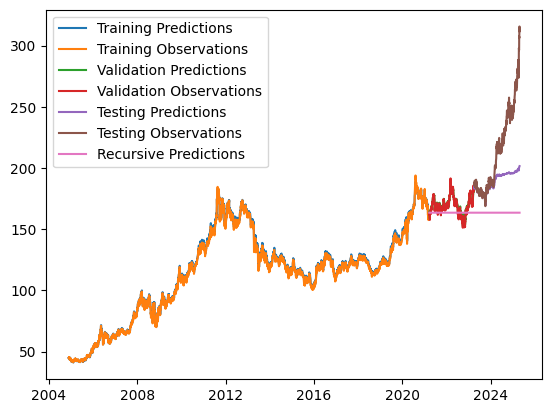

In [ ]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.plot(recursive_dates, recursive_predictions)
plt.legend(
    [
        "Training Predictions",
        "Training Observations",
        "Validation Predictions",
        "Validation Observations",
        "Testing Predictions",
        "Testing Observations",
        "Recursive Predictions",
    ]
)